In [1]:
import wfdb
import os
import pandas as pd
from pathlib import Path
import numpy as np

In [3]:
DATA_DIR = "data/PTB_XL"   # adjust if needed

print("=== PTB_XL Dataset Explorer ===\n")

# List all records
records = wfdb.get_record_list('ptb-xl')
print(f"Total records: {len(records)}\n")

=== PTB_XL Dataset Explorer ===

Total records: 43597



In [17]:
# Load metadata
# metadata = pd.read_csv(f"{DATA_DIR}/ludb.csv")
# print("\nMetadata head:")
# display(metadata.head())

# Analyze one record as example
record_name = "00001_hr"
print(f"\n=== Example Record: {record_name} ===")

record = wfdb.rdrecord(record_name, pn_dir='ptb-xl/records500/00000')
print(f"Sampling rate: {record.fs} Hz")
print(f"Duration: {record.sig_len / record.fs:.2f} seconds")
print(f"Number of channels: {record.n_sig}")
print(f"Channel names: {record.sig_name}")


=== Example Record: 00001_hr ===
Sampling rate: 500 Hz
Duration: 10.00 seconds
Number of channels: 12
Channel names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [6]:
# mask_a = metadata["Electric axis of the heart"]=="Electric axis of the heart: normal"
# mask_b = metadata["Rhythms"]=="Sinus rhythm"
# data = metadata.loc[mask_a & mask_b].drop(columns=["Sex","Age"])
# data

In [14]:
np.load("data/staff_III/n_sig_series.pkl", allow_pickle=True)

001a    9.0
001b    9.0
001c    9.0
001d    9.0
002a    9.0
       ... 
108a    9.0
108b    9.0
108c    9.0
108d    9.0
108e    9.0
Name: n_sig, Length: 520, dtype: float64

In [23]:
import pickle as pkl
np.save(f"data/ptb-xl/00001_hr.npy", record.p_signal.T)
data = {"fs":500, "channels": ["I", "II", "III","aVR", "aVL", "aVF","V1", "V2", "V3", "V4", "V5", "V6"]}

with open(f"data/ptb-xl/00001_hr.pkl", "wb") as f:
    pkl.dump(data, f)

print(record.p_signal.T.shape)

(12, 5000)


{'fs': 500,
 'channels': ['I',
  'II',
  'III',
  'aVR',
  'aVL',
  'aVF',
  'V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6']}

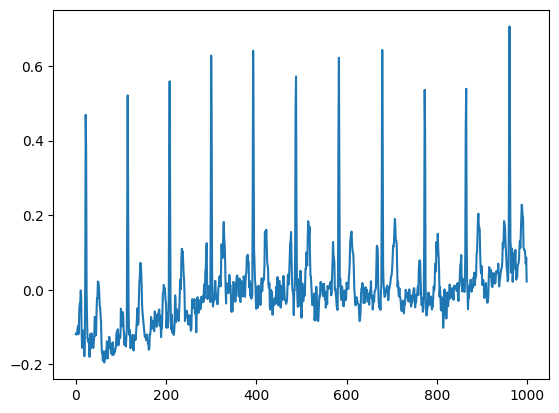

In [7]:
import matplotlib.pyplot as plt
plt.plot(record.p_signal.T[0])

In [39]:
# See the properties of record
print("\nRecord properties:")
for key, value in record.__dict__.items():
    if key != 'p_signal':  # skip the actual signal data for brevity
        print(f"{key}: {value}")


Record properties:
record_name: 1
n_sig: 12
fs: 500
counter_freq: None
base_counter: None
sig_len: 5000
base_time: None
base_date: None
comments: ['<age>: 51', '<sex>: F', '<diagnoses>:', 'Rhythm: Sinus bradycardia.', 'Electric axis of the heart: left axis deviation.', 'Left ventricular hypertrophy.', 'Left ventricular overload.', 'Non-specific repolarization abnormalities: posterior wall.']
sig_name: ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6']
d_signal: None
e_p_signal: None
e_d_signal: None
file_name: ['1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat', '1.dat']
fmt: ['16', '16', '16', '16', '16', '16', '16', '16', '16', '16', '16', '16']
samps_per_frame: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
skew: [None, None, None, None, None, None, None, None, None, None, None, None]
byte_offset: [None, None, None, None, None, None, None, None, None, None, None, None]
adc_gain: [1716.0, 1206.0, 1229.0, 1368.0, 1368.0, 6

In [33]:
# Quick stats per lead
print("\nSignal statistics per lead:")
for i, lead in enumerate(record.sig_name):
    sig = record.p_signal[:, i]
    print(f"  {lead:4}: mean={sig.mean():.2f}, std={sig.std():.2f}, range=[{sig.min():.1f}, {sig.max():.1f}]")


Signal statistics per lead:
  i   : mean=0.00, std=0.11, range=[-0.1, 0.9]
  ii  : mean=0.00, std=0.10, range=[-0.1, 0.9]
  iii : mean=0.00, std=0.07, range=[-0.8, 0.2]
  avr : mean=0.00, std=0.11, range=[-0.9, 0.1]
  avl : mean=0.00, std=0.10, range=[-0.1, 0.9]
  avf : mean=0.00, std=0.07, range=[-0.4, 0.6]
  v1  : mean=0.00, std=0.10, range=[-0.8, 0.2]
  v2  : mean=0.00, std=0.13, range=[-0.4, 0.6]
  v3  : mean=0.00, std=0.11, range=[-0.2, 0.8]
  v4  : mean=0.00, std=0.10, range=[-0.2, 0.8]
  v5  : mean=0.00, std=0.10, range=[-0.1, 0.9]
  v6  : mean=0.00, std=0.10, range=[-0.1, 0.9]


In [68]:
from tqdm import tqdm

def parse_comments(comments_list):
    """
    Parse record comments into a dictionary of diagnostic fields.
    """
    result = {
        'Rhythm': None,
        'Electric axis of the heart': None,
        'Conduction abnormalities': None,
        'Extrasystolies': None,
        'Hypertrophies': None,
        'Cardiac pacing': None,
        'Ischemia': None,
        'Non-specific repolarization abnormalities': None,
        'Other states': None,
    }
    
    if not comments_list:
        return result
    
    comments_text = '\n'.join(comments_list)
    
    for key in result.keys():
        import re
        pattern = rf'^{re.escape(key)}\s*:\s*(.+?)(?=\n[A-Z]|\Z)'
        matches = re.findall(pattern, comments_text, re.MULTILINE | re.IGNORECASE)
        
        if matches:
            result[key] = '; '.join([m.strip().replace(".","").replace(" ","") for m in matches])
    
    return result


def build_metadata_dataframe(records_list, n=200):
    """
    Build metadata DataFrame with record_name, n_sig, fs, sig_len, baseline.
    """
    data_rows = []
    
    print(f"Processing {len(records_list)} records for metadata...")
    
    for record_idx, record_name in tqdm(enumerate(records_list[:n]), desc="Metadata"):
        if (record_idx + 1) % 25 == 0:
            print(f"  Processed {record_idx + 1}/{len(records_list)}...")
        
        try:
            record = wfdb.rdrecord(record_name, pn_dir='ludb/data')
            
            row_data = {
                'record_name': record_name,
                'n_sig': record.n_sig,
                'fs': record.fs,
                'sig_len': record.sig_len,
                'baseline': record.baseline if hasattr(record, 'baseline') else None,
            }
            
            data_rows.append(row_data)
        
        except Exception as e:
            print(f"  ⚠ Error loading {record_name}: {str(e)[:60]}")
            continue
    
    print(f"✓ Successfully loaded {len(data_rows)} records\n")
    return pd.DataFrame(data_rows).set_index('record_name')


def build_labels_dataframe(records_list, n=200):
    """
    Build labels DataFrame with diagnostic information.
    """
    data_rows = []
    
    print(f"Processing {len(records_list)} records for labels...")
    
    for record_idx, record_name in tqdm(enumerate(records_list[:n]), desc="Labels"):
        if (record_idx + 1) % 25 == 0:
            print(f"  Processed {record_idx + 1}/{len(records_list)}...")
        
        try:
            record = wfdb.rdrecord(record_name, pn_dir='ludb/data')
            
            row_data = {'record_name': record_name}
            comments_dict = parse_comments(record.comments)
            row_data.update(comments_dict)
            
            data_rows.append(row_data)
        
        except Exception as e:
            print(f"  ⚠ Error loading {record_name}: {str(e)[:60]}")
            continue
    
    print(f"✓ Successfully loaded {len(data_rows)} records\n")
    return pd.DataFrame(data_rows).set_index('record_name')


def build_data_dataframe(records_list, n):
    """
    Build data DataFrame with signal columns (capitalized lead names enforced).
    """
    # Standard 12-lead ECG lead names (capitalized)
    STANDARD_LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    
    data_rows = []
    
    print(f"Processing {len(records_list)} records for signal data...")
    
    for record_idx, record_name in enumerate(records_list[:n]):
        if (record_idx + 1) % 25 == 0:
            print(f"  Processed {record_idx + 1}/{len(records_list)}...")
        
        try:
            record = wfdb.rdrecord(record_name, pn_dir='ludb/data')
            
            row_data = {'record_name': record_name}
            
            # Enforce capitalized signal names (override record.sig_name)
            signal_data = record.p_signal  # Shape: (sig_len, n_sig)
            sig_names = STANDARD_LEADS[:record.n_sig]
            
            for ch_idx, sig_name in enumerate(sig_names):
                row_data[sig_name] = signal_data[:, ch_idx]
            
            data_rows.append(row_data)
        
        except Exception as e:
            print(f"  ⚠ Error loading {record_name}: {str(e)[:60]}")
            continue
    
    print(f"✓ Successfully loaded {len(data_rows)} records\n")
    return pd.DataFrame(data_rows).set_index('record_name')

records_list = wfdb.get_record_list('ludb')


In [92]:
df_metadata = build_metadata_dataframe(records_list,200)
print(f"Metadata shape: {df_metadata.shape}")
print("\n=== Metadata Sample ===")
display(df_metadata.head())
df_metadata.to_csv("data/LU_DB/maps/metadata.csv")


Processing 200 records for metadata...


Metadata: 24it [01:34,  3.65s/it]

  Processed 25/200...


Metadata: 49it [03:09,  3.75s/it]

  Processed 50/200...


...

Metadata: 199it [11:30,  3.81s/it]

  Processed 200/200...


Metadata: 200it [11:33,  3.47s/it]

✓ Successfully loaded 200 records

Metadata shape: (200, 4)

=== Metadata Sample ===


,n_sig,fs,sig_len,baseline
record_name,,,,
data/1,12,500,5000,"[6, 2, -5, -5, 5, -1, -1, 2, 3, 4, 4, 1]"
data/2,12,500,5000,"[-3, 1, 3, 0, -3, 2, 0, 1, -1, 1, 5, 1]"
data/3,12,500,5000,"[-4, -1, 2, 2, -4, 0, -2, 0, -2, 1, 1, 1]"
data/4,12,500,5000,"[8, 9, 1, -10, 3, 5, -3, -6, -6, -6, -3, -8]"
data/5,12,500,5000,"[2, 0, -2, -2, 2, -1, -2, 1, 3, 1, 0, -5]"


In [93]:
df_labels = build_labels_dataframe(records_list, 200)
print(f"Labels shape: {df_labels.shape}")
print("\n=== Labels Sample ===")
display(df_labels.head())

# Get diagnostic columns (everything except record_name)
df_labels.to_csv("data/LU_DB/maps/labels.csv")

Processing 200 records for labels...


Labels: 24it [01:24,  2.79s/it]

  Processed 25/200...


Labels: 49it [02:48,  3.45s/it]

  Processed 50/200...


...

Labels: 199it [12:00,  4.93s/it]

  Processed 200/200...


Labels: 200it [12:03,  3.62s/it]

✓ Successfully loaded 200 records

Labels shape: (200, 9)

=== Labels Sample ===


,Rhythm,Electric axis of the heart,Conduction abnormalities,Extrasystolies,Hypertrophies,Cardiac pacing,Ischemia,Non-specific repolarization abnormalities,Other states
record_name,,,,,,,,,
data/1,Sinusbradycardia,leftaxisdeviation,None,None,None,None,None,posteriorwall,None
data/2,Sinusrhythm,normal,None,None,None,None,None,posteriorwall,None
data/3,Sinusrhythm,vertical,None,None,None,None,lateralwall; inferiorwall,None,None
data/4,Sinusrhythm,leftaxisdeviation,None,None,None,None,inferiorwall,None,None
data/5,Sinusrhythm,horizontal,None,None,None,None,None,inferiorwall,None


In [94]:
import pickle as pkl

df_data = build_data_dataframe(records_list, 200)
print(f"Data shape: {df_data.shape}")
print("\n=== Data Columns ===")
print(list(df_data.columns))
df_data.to_csv("data/LU_DB/maps/data.csv")

with open("data/LU_DB/maps/data.pkl", "wb") as f:
    pkl.dump(df_data, f)

Processing 200 records for signal data...
  Processed 25/200...
  Processed 50/200...
  Processed 75/200...
  Processed 100/200...
  Processed 125/200...
  Processed 150/200...
  Processed 175/200...
  Processed 200/200...
✓ Successfully loaded 200 records

Data shape: (200, 12)

=== Data Columns ===
['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [91]:
loaded_data = pkl.load(open("data/LU_DB/maps/data.pkl", "rb"))
loaded_data

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
record_name,,,,,,,,,,,,
data/1,"[-0.07342657342657342, -0.028554778554778556, ...","[0.019071310116086235, 0.07877280265339967, 0....","[0.12205044751830757, 0.11798209926769732, 0.1...","[0.038011695906432746, -0.01608187134502924, -...","[-0.10014619883040936, -0.07017543859649122, -...","[0.12320916905444126, 0.17048710601719197, 0.2...","[0.11005830903790087, 0.13702623906705538, 0.1...","[0.03816793893129771, 0.10368956743002544, 0.2...","[0.027445772465692783, 0.09163346613545817, 0....","[0.06085455330168321, 0.1320673284419508, 0.21...","[0.048698167791706846, 0.11137897782063645, 0....","[-0.017844886753603295, 0.045298558682223745, ..."
data/2,"[-0.21031746031746032, -0.18121693121693122, -...","[0.050514499532273154, 0.047708138447146865, 0...","[0.3026874115983027, 0.26732673267326734, 0.31...","[0.06455542021924482, 0.0535931790499391, 0.09...","[-0.4325581395348837, -0.37906976744186044, -0...","[0.15857988165680473, 0.14201183431952663, 0.1...","[0.059202059202059204, 0.06885456885456885, 0....","[0.047093451066961, 0.06328182487122884, 0.059...","[-0.023882896764252697, -0.00847457627118644, ...","[-0.007080610021786492, 0.0032679738562091504,...","[0.08971840209561231, 0.10150622134905042, 0.0...","[-0.0026455026455026454, 0.005291005291005291,..."
data/3,"[-0.011984021304926764, -0.03062583222370173, ...","[-0.03641160949868074, -0.02163588390501319, -...","[-0.029107054760730142, -0.008386778490379871,...","[0.03865213082259663, 0.031714568880079286, 0....","[0.020700636942675158, -0.0015923566878980893,...","[-0.03292181069958848, -0.014917695473251029, ...","[-0.010958904109589041, 0.006575342465753425, ...","[0.017408123791102514, 0.02321083172147002, 0....","[-0.030492030492030493, -0.02702702702702703, ...","[-0.005672609400324149, -0.0008103727714748784...","[-0.008760951188986232, -0.00458906967042136, ...","[-0.03985507246376811, -0.035024154589371984, ..."
data/4,"[-0.08918249380677126, -0.046242774566473986, ...","[0.4372523117569353, 0.5257595772787318, 0.486...","[0.3333333333333333, 0.3447228549734245, 0.356...","[-0.11702127659574468, -0.1797872340425532, -0...","[-0.22213181448331978, -0.20667209113100082, -...","[0.47530864197530864, 0.5259259259259259, 0.51...","[-0.004519774011299435, -0.007909604519774011,...","[-0.15051457975986277, -0.15051457975986277, -...","[-0.16747572815533981, -0.16949838187702265, -...","[-0.15454906634882798, -0.1573301549463647, -0...","[-0.0800395256916996, -0.08498023715415019, -0...","[-0.20337738619676946, -0.20704845814977973, -..."
data/5,"[0.156794425087108, 0.2229965156794425, 0.1794...","[0.09219858156028368, 0.11524822695035461, 0.1...","[-0.09336609336609336, -0.1547911547911548, -0...","[-0.12727272727272726, -0.17272727272727273, -...","[0.16120906801007556, 0.24181360201511334, 0.1...","[0.02064896755162242, 0.0029498525073746312, 0...","[-0.022091310751104567, -0.044182621502209134,...","[0.3313008130081301, 0.31402439024390244, 0.32...","[0.3324624428478119, 0.32919660352710645, 0.33...","[0.21406991799741046, 0.20889080707811825, 0.2...","[0.1445587439090417, 0.1337303735787764, 0.144...","[0.07768361581920905, 0.06497175141242938, 0.0..."
